# Route Finding with Public Transport Dataset

Welcome to this notebook! 🚍🗺️  

This notebook demonstrates how to find public transport routes near a given location.

- **Input:** A starting point on the map (latitude and longitude) and a search radius.  
- **Output:** Public transport routes that have stops within the given radius.  

In addition to route discovery, this notebook will guide you through:

1. **Visualizing the query location:** Plotting the initial point and radius on a map.  
2. **Visualizing routes:** Displaying the matched routes.

Let's get started! 🚀

# Loading Data

The first step in this notebook is to load the transport data from a **Parquet file**. 

This file contains all the essential information needed for route finding, including:

- **Routes:** The different public transport lines available.  
- **Trips:** Individual scheduled trips for each route.  
- **Stops:** Geographic locations of each stop on the routes.  

Let's load the data and take a quick look at its structure.

In [1]:
from pathlib import Path

import pandas as pd


root = Path("..")

parquet_path = Path(root / "data/postauto.parquet")
df = pd.read_parquet(parquet_path)
print(f"DataFrame contains {len(df)} rows")
df.head()

DataFrame contains 519177 rows


,agency_id,route_id,route_short_name,trip_id,service_id,stop_sequence,arrival_time,departure_time,stop_id,stop_name,stop_lat,stop_lon
0,801,96-100-0-j25-1,220,2.TA.96-100-0-j25-1.8.H,TA,1,18:27:00,18:27:00,8571330,"Reichenbach i. K., Bahnhof",46.625525,7.690208
1,801,96-100-0-j25-1,220,2.TA.96-100-0-j25-1.8.H,TA,2,18:28:00,18:28:00,8571331,"Reichenbach i. K., Bären",46.625432,7.694187
2,801,96-100-0-j25-1,220,2.TA.96-100-0-j25-1.8.H,TA,3,18:30:00,18:30:00,8583254,"Scharnachtal, Halten",46.620608,7.697223
3,801,96-100-0-j25-1,220,2.TA.96-100-0-j25-1.8.H,TA,4,18:32:00,18:32:00,8507766,"Scharnachtal, Viesen",46.617979,7.697807
4,801,96-100-0-j25-1,220,2.TA.96-100-0-j25-1.8.H,TA,5,18:33:00,18:33:00,8571332,"Scharnachtal, Schulhaus",46.614709,7.698158


# Formulating a Query

To find routes near a specific location, we first define a **query** using the `RadiusQuery` object.  

This object contains:

- **Latitude (`lat`)** – The starting point's latitude.  
- **Longitude (`lon`)** – The starting point's longitude.  
- **Radius (`radius`)** – The search radius around the point (in meters).  

Once the query is defined, we visualize it on a map using **Matplotlib** and **Cartopy**, which helps to:

- See the query location clearly.  
- Verify that the radius covers the area of interest.

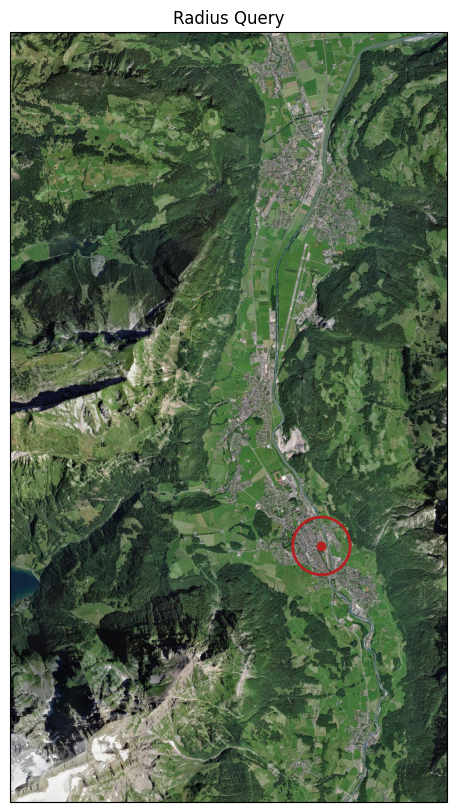

In [2]:
import cartopy.crs as ccrs
import cartopy.geodesic as cgeo
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
from loguru import logger

logger.remove() # prevent ocsept from logging

from trip_stitcher.models import RadiusQuery


def create_map_plot(extent):
    # Create a tiler for OpenStreetMap
    tiler = cimgt.GoogleTiles(style="satellite")   # Satellite tiles
    mercator = tiler.crs  # The CRS used by the tiles (Web Mercator)
    
    # Create the plot
    fig = plt.figure(figsize=(10,10))
    ax = plt.axes(projection=mercator)
    
    # Add the map tiles
    ax.add_image(tiler, 14)  # zoom level 14
    
    # Set extent
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    return ax, plt


radius_query = RadiusQuery(lat=47.03994, lon=9.07124, radius=500)
extent = [9.0, 9.1, 47.0, 47.12]

ax, plt = create_map_plot(extent)

# Plot query point
ax.scatter([radius_query.lon], [radius_query.lat], transform=ccrs.PlateCarree(), c="firebrick")

# Generate geodesic circle points
circle_points = cgeo.Geodesic().circle(lon=radius_query.lon, lat=radius_query.lat, radius=radius_query.radius, n_samples=100)

# Plot query radius
ax.plot(circle_points[:,0], circle_points[:,1], color='firebrick', linewidth=2, transform=ccrs.PlateCarree())

plt.title("Radius Query")
plt.show()

# Initializing the Route Locator

To efficiently find routes near a query location, we create a **`RouteLocator`** object.  

This object does two key things:

1. **Maps stops to routes** – Each stop is linked to the routes that pass through it, making it easy to identify relevant routes quickly.  
2. **Stores stops in a BallTree** – This spatial data structure enables extremely fast nearest-neighbor searches, allowing us to efficiently find stops within a given radius.  

While constructing the `RouteLocator` can take a few seconds, it sets up the dataset for **rapid and repeated spatial queries**, making the route-finding very fast.

In [11]:
from trip_stitcher.models import Route, Stop, Trip
from trip_stitcher.route_locator import RouteLocator


trip_dict = dict((trip.id, trip) for trip in Trip.list_from_dataframe(df)) # Trip dictionary for trip lookup
stop_dict = dict((stop.id, stop) for stop in Stop.list_from_dataframe(df)) # Stop dictionary for stop lookup
route_locator = RouteLocator(
    Route.list_from_dataframe(df), Trip.list_from_dataframe(df), Stop.list_from_dataframe(df)
)

In [12]:
routes = route_locator.radius_query(radius_query)
print(f"Found {len(routes)} Routes:")
for i, route in enumerate(routes):
    print(f"  {i+1}. {route.name} ({route.id})")

Found 3 Routes:
  1. 501 (96-241-7-j25-1)
  2. 503 (96-241-5-j25-1)
  3. 502 (96-241-8-j25-1)


# Visualizing Routes

After finding the routes near our query location, we visualize them on the map.  

Since a route can have multiple trips with different stop sequences, we first select a **representative trip** for each route:  

- We use the convenient **`.find_representative_trip()`** method, which returns the trip whose **stop sequence occurs most frequently** among all trips on that route.  
- Once we have a representative trip, we call **`.download_geometry()`**, which returns a **`TripGeometry`** object containing the exact coordinates of the trip. This uses **Open Source Routing Machine (OSRM)** to generate the path.  

We then plot these representative trips on the map.  

⚠️ **Note:** Some trips may overlap on the map, so certain routes might not be fully distinguishable in congested areas.

In [13]:
rtrips = [route.find_representative_trip(trip_dict) for route in routes]

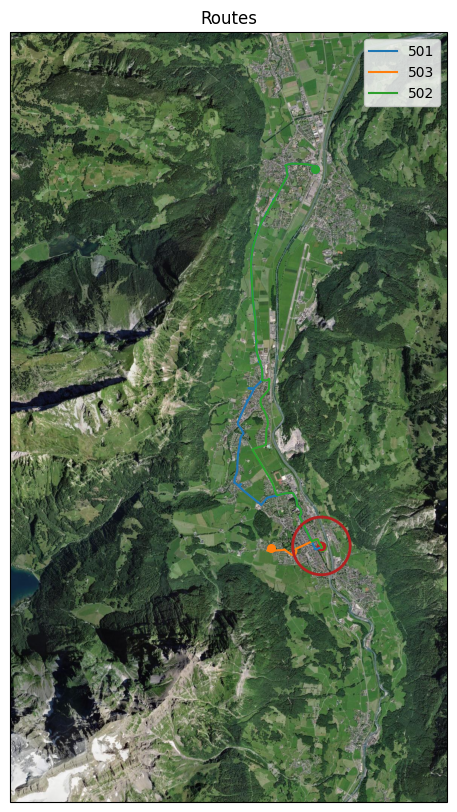

In [14]:
ax, plt = create_map_plot(extent)

for rtrip, route in zip(rtrips, routes):
    trip_geometry = rtrip.download_geometry(stop_dict)
    ax.plot(trip_geometry.lon, trip_geometry.lat, transform=ccrs.PlateCarree(), label=route.name)
    ax.scatter([trip_geometry.lon[0], trip_geometry.lon[-1]], [trip_geometry.lat[0], trip_geometry.lat[-1]], s=30, transform=ccrs.PlateCarree())

# Plot radius query
ax.scatter([radius_query.lon], [radius_query.lat], transform=ccrs.PlateCarree(), c="firebrick")
circle_points = cgeo.Geodesic().circle(lon=radius_query.lon, lat=radius_query.lat, radius=radius_query.radius, n_samples=100)
ax.plot(circle_points[:,0], circle_points[:,1], color='firebrick', linewidth=2, transform=ccrs.PlateCarree())

plt.title("Routes")
plt.legend()
plt.show()